In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from src.simulations.Rebound_v4 import OrbitalSimulation
from numpy.random import SeedSequence, Generator, PCG64
import src.utils.calculations_v3 as calc
import multiprocessing
import datetime
from numpy.random import SeedSequence, Generator, PCG64
import src.simulations.MonteCarlo_impsamp_v4 as MCi
import src.configurations.Configuration as conf
import src.analysis.Analysis_v2 as anl
import src.plotting.Plotting_v2 as pl
import datetime as dt
import tdpy as td
# Simulation Runs
mPBH_grid = np.linspace(1.5e-7, 1e-4, 10) * const.M_sun.value  # from 1e-10 to 1 solar mass
mPBH_grid = np.logspace(np.log10(1e-8), np.log10(1e-4), 5) * const.M_sun.value  # from 1e-10 to 1 solar mass
print(mPBH_grid)
run_dict = {}
for i, mPBH in enumerate(mPBH_grid):
    seed = i  # Just a way to get different seeds
    name = f"Sun_Jupiter_s{seed}_calcv3_MCv4_reboundV4"
    configuration = conf.Configuration(name=name, seed=seed, importance_sampling=True)
    configuration.set_system_param('mC', mPBH)  # Mass of light PBH
    configuration.set_simulation_param('sample_size', 500)  # Mass of light PBH
    configuration.set_simulation_param('max_trials', 1000000000)  # Mass of light PBH
    max_v_default = configuration.get_simulation_param(all=True)['v_inf_grid'][-1]
    configuration.set_simulation_param('max_v', max_v_default*0.75) # From Dehnen 2022, for circular Jupiter 31.6 km/s
    configuration.print_configuration()
    run_dict[name] = {'name': name, 'seed': seed, 'configuration': configuration}
    print(f"Prepared configuration for mPBH = {mPBH / const.M_sun.value} solar masses.\n")


Using REPO_ROOT: /data/a.saricaoglu/repo/captus


/data/a.saricaoglu/repo/captus/src/plotting/Plotting_v2.py:689: SyntaxWarning: invalid escape sequence '\o'
  zkey = zkey / const.M_sun.value if 'M$_{\odot}$' in analysis_zlabel else zkey
/data/a.saricaoglu/repo/captus/src/plotting/Plotting_v2.py:1618: SyntaxWarning: invalid escape sequence '\%'
  Threshold for KDE contours (0.1 = 10\% of max density)
/data/a.saricaoglu/repo/captus/src/plotting/Plotting_v2.py:1826: SyntaxWarning: invalid escape sequence '\%'
  Threshold for KDE contours (0.1 = 10\% of max density)


[1.98840987e+22 1.98840987e+23 1.98840987e+24 1.98840987e+25
 1.98840987e+26]
Updated system parameter 'mC' to 1.988409870698051e+22 and recalculated rC.
Updated v_inf_grid_params 'max_v' to 30373.502689578207 and regenerated v_inf_grid.
System Parameters:
  mA: 1.988409870698051e+30
  mB: 1.8981245973360505e+27
  mC: 1.988409870698051e+22
  aB: 777908927640.0
  rB: 71492000.0
  rA: 696265000.0
  vB: 13060.0
  eB: 0.0489
  iB: 0.02275909344600606
  epsilon: 0.1
  name: Sun_Jupiter_s0_calcv3_MCv4_reboundV4
  seed_base: 0
  rC: 2.9532500761002496e-05

Simulation Parameters:
  trials: 10000000
  max_trials: 1000000000
  max_execution_time: 3600
  sample_size: 500
  max_e: 1.0
  vDM: 220000.0
  v_inf_grid_params: {'min_v': 1000, 'max_v': np.float64(30373.502689578207), 'n_v': 10}
  importance_sampling: True
  v_inf_grid: [ 1000.          4263.72252106  7527.44504213 10791.16756319
 14054.89008426 17318.61260532 20582.33512639 23846.05764745
 27109.78016851 30373.50268958]
Prepared configur

In [2]:
for run in list(run_dict.values()):

    configuration = run['configuration']
    name = run['name']
    analysis = anl.Analysis(name=configuration.name, configuration=configuration)
    mc = analysis.get_mc_results()
    cd = analysis.get_combined_dictionary()
    # print(cd.keys())
    sampled_mc = analysis.get_sampled_mc_results()
    # print(sampled_mc['v1'].keys())
    run_dict[name]['sampled_mc'] = sampled_mc
    # Debug: Check MC data structure and read inclinations

        

    

Loading MC results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s0_calcv3_MCv4_reboundV4/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/Sun_Jupiter_s0_calcv3_MCv4_reboundV4/Rebound_Simulation_Results/
captured objects for v_inf = V1 km/s: 500
v_inf = V1 km/s: sampled 500 captured objects
captured objects for v_inf = V4 km/s: 500
v_inf = V4 km/s: sampled 500 captured objects
captured objects for v_inf = V8 km/s: 500
v_inf = V8 km/s: sampled 500 captured objects
captured objects for v_inf = V11 km/s: 500
v_inf = V11 km/s: sampled 500 captured objects
captured objects for v_inf = V14 km/s: 500
v_inf = V14 km/s: sampled 500 captured objects
captured objects for v_inf = V17 km/s: 500
v_inf = V17 km/s: sampled 500 captured objects
captured objects for v_inf = V21 km/s: 500
v_inf = V21 km/s: sampled 500 captured objects
captured objects for v_inf = V24 km/s: 500
v_inf = V24 km/s: sampled 500 captured objects
captured objects for v_inf = V27 km/

In [33]:
# import rebound
# def check_rebound_trajectories(mA, mB, mC, rA, rB, rC, pos_C, v_C, pos_B, v_B ):
#         mA = (mA*u.kg).to(u.Msun).value
#         mB = (mB*u.kg).to(u.Msun).value
#         mC = (mC*u.kg).to(u.Msun).value
#         rA = (rA*u.m).to(u.au).value
#         rB = (rB*u.m).to(u.au).value
#         rC = (rC*u.m).to(u.au).value
#         pos_C = (np.array(pos_C) * u.m).to(u.au).value
#         v_C = (np.array(v_C) * u.m/u.s).to(u.au/u.yr).value
#         pos_B = (np.array(pos_B) * u.m).to(u.au).value
#         v_B = (np.array(v_B) * u.m/u.s).to(u.au/u.yr).value
#         # Gravitational parameter in these units: G = 4*pi^2 AU^3/(Msun*yr^2)
#         sim = rebound.Simulation()
#         sim.units = ('AU', 'yr', 'Msun')
#         sim.integrator = "MERCURIUS"
#         sim.add(m=mA, r=rA)  # Sun
#         sim.add(m=mB, r=rB, x=pos_B[0], y=pos_B[1], z=pos_B[2], vx=v_B[0], vy=v_B[1], vz=v_B[2])  # Jupiter
#         sim.add(m=mC, r=rC, x=pos_C[0], y=pos_C[1], z=pos_C[2], vx=v_C[0], vy=v_C[1], vz=v_C[2])  # PBH

#         G_unit = sim.G  # 4*pi^2 in these units
#         sim.move_to_com()

#         a_init = sim.particles[2].orbit(primary=sim.particles[0]).a
#         e_init = sim.particles[2].orbit(primary=sim.particles[0]).e
#         Evc = 0.5 * (sim.particles[2].vx**2 + sim.particles[2].vy**2 + sim.particles[2].vz**2)
#         rAC = np.abs(sim.particles[2] ** sim.particles[0])
#         E_c_cond = Evc - (G_unit*(sim.particles[0].m + sim.particles[2].m) / rAC)
#         ec = (E_c_cond < 0)
#         captured =  ec & (e_init < 1) & (a_init > 0)
#         if captured:
#             c= 'green'
#         elif ec:
#             c= 'blue'
#         else:
#             c= 'red'

#         return E_c_cond, a_init, e_init, c
        

        
# # Visualize initial conditions from actual sampled_mc data
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D
# import src.utils.calculations_v3 as calc
# %matplotlib widget
j, k = 50, 50
# Get data from sampled_mc (already loaded)
for run in list(run_dict.values())[0:1]:  # Just do it for the first run for now
    configuration = run['configuration']
    sampled_mc = run['sampled_mc']
    name = run['name']
    mA = configuration.get_system_param('mA')
    mB = configuration.get_system_param('mB')
    mC = configuration.get_system_param('mC')
    rA = configuration.get_system_param('rA')  # Schwarzschild radius of the Sun, used for Rebound particle radius  
    rB = configuration.get_system_param('rB')  # Jupiter radius, used for Rebound particle radius
    rC = configuration.get_system_param('rC')  # PBH radius, used for Rebound particle radius
    epsilon = configuration.get_system_param('epsilon')  # Softening parameter for r_close calculation
    vBMag = configuration.get_system_param('vB')  # Jupiter velocity magnitude
    muA = calc.standard_gravitational_parameter(mA, mC)
    muB = calc.standard_gravitational_parameter(mB, mC)
    aB = configuration.get_system_param('aB')
    rClose = calc.r_close(epsilon, muA, muB, aB)
    sys_with_failed_capture = {}
    v_keys = list(sampled_mc.keys())
    for m in v_keys:
        sys_with_failed_capture[m] = {}
        v_inf = sampled_mc[m]['v_inf']
        for idx in range(100):  # Loop through all captured samples
        # Get the parameters
            pos_C_m = sampled_mc[m]['cap_C_pos'][idx]  # Exit position in meters
            pos_B_m = sampled_mc[m]['cap_B_pos'][idx]  # Jupiter position
            v_C_m_s = sampled_mc[m]['cap_C_v2'][idx]   # v2' in m/s
            v_B_m_s = sampled_mc[m]['cap_B_v'][idx]    # vB in m/s
            # v1prime_m_s = sampled_mc[m]['cap_C_v1prime'][idx]  # v1' in m/s
            v2Mag = np.linalg.norm(v_C_m_s)
            # Sample a population with different exit positions over r close sphere in spherical coordinates (theta, phi) to visualize the hyperbolic trajectories
            exit_positions = []
            exit_angles = []
            for theta in np.linspace(0, 2 * np.pi, j):
                for phi in np.linspace(0, np.pi, k):
                    exit_at_rclose = [rClose * np.cos(theta) * np.sin(phi)  , rClose * np.sin(theta) * np.sin(phi),  rClose * np.cos(phi)]
                    exit_positions.append(exit_at_rclose)
                    exit_angles.append((theta, phi))
            # Calculate energy and angular momentum for each exit position to check the capture condition
            exit_positions.append([0, 0, 0])
            energies = []
            angular_momenta = []
            a_l, e_l= [], []
            exit_pos_A_frame = []
            colors = []
            energies_rebound, a_rebound, e_rebound, colors_rebound = [], [], [], []
            for exit in exit_positions:
                exit_in_A_frame = exit + pos_B_m  # Transform exit position from B frame to A frame
                energy = 0.5 * v2Mag**2 - muA / np.linalg.norm(exit_in_A_frame)
                angular_momentum = calc.specific_L2(exit_in_A_frame, v_C_m_s)
                a, e = calc.a_e(muA, energy, angular_momentum)
                ec = (energy < 0)
                captured =  ec & (e < 1) & (a > 0)
                if captured:
                    c= 'green'
                elif ec:
                    c= 'blue'
                else:
                    c= 'red'
                colors.append(c)
                a_l.append(a)
                e_l.append(e)       
                exit_pos_A_frame.append(exit_in_A_frame)
                energies.append(energy)
                # Check with Rebound
                # E_rebound, a_rebound_val, e_rebound_val, c_rebound = check_rebound_trajectories(mA, mB, mC, rA, rB, rC, exit_in_A_frame, v_C_m_s, pos_B_m, v_B_m_s)
                # energies_rebound.append(E_rebound)
                # a_rebound.append(a_rebound_val)
                # e_rebound.append(e_rebound_val)
                # colors_rebound.append(c_rebound)
            c1 = colors.count('red')
            # c2 = colors_rebound.count('red')
            if c1 > 0:
                print(f"Red trajectories found for v_inf = {v_inf:.2f} m/s, idx = {idx}, c1 = {c1}")
                sys_with_failed_capture[m][idx] = {
                    'exit_positions': exit_pos_A_frame,
                    'energies': energies,
                    'angular_momenta': angular_momenta,
                    'a_l': a_l,
                    'e_l': e_l,
                    'colors': colors,
                    'exit_angles': exit_angles,
                    # 'energies_rebound': energies_rebound,
                    # 'a_rebound': a_rebound,
                    # 'e_rebound': e_rebound,
                    # 'colors_rebound': colors_rebound
                }
    run_dict[name]['sys_with_failed_capture'] = sys_with_failed_capture


Red trajectories found for v_inf = 1000.00 m/s, idx = 2, c1 = 2033
Red trajectories found for v_inf = 1000.00 m/s, idx = 3, c1 = 268
Red trajectories found for v_inf = 1000.00 m/s, idx = 6, c1 = 728
Red trajectories found for v_inf = 1000.00 m/s, idx = 9, c1 = 642
Red trajectories found for v_inf = 1000.00 m/s, idx = 11, c1 = 2279
Red trajectories found for v_inf = 1000.00 m/s, idx = 13, c1 = 1793
Red trajectories found for v_inf = 1000.00 m/s, idx = 14, c1 = 358
Red trajectories found for v_inf = 1000.00 m/s, idx = 15, c1 = 2325
Red trajectories found for v_inf = 1000.00 m/s, idx = 17, c1 = 2291
Red trajectories found for v_inf = 1000.00 m/s, idx = 19, c1 = 1749
Red trajectories found for v_inf = 1000.00 m/s, idx = 20, c1 = 1955
Red trajectories found for v_inf = 1000.00 m/s, idx = 21, c1 = 1795
Red trajectories found for v_inf = 1000.00 m/s, idx = 24, c1 = 2003
Red trajectories found for v_inf = 1000.00 m/s, idx = 25, c1 = 2097
Red trajectories found for v_inf = 1000.00 m/s, idx = 27

In [34]:
per = []
for v in sys_with_failed_capture.keys():
    failed_percentages = []
    counter = 0
    origin_failure = 0
    for idx in sys_with_failed_capture[v].keys():
        counter+=1
        data = sys_with_failed_capture[v][idx]
        exit_positions = np.array(data['exit_positions'])
        colors = data['colors']
        energies = data['energies']
        a_l = data['a_l']
        e_l = data['e_l']
        # energies_rebound = data['energies_rebound']
        # a_rebound = data['a_rebound']
        # e_rebound = data['e_rebound']
        # colors_rebound = data['colors_rebound']
        f = colors.count('red') + colors.count('blue')
        p = (f/(j*k+1)) * 100
        failed_percentages.append(p)
        if colors[-1] == 'red':
            origin_failure+=1
    of_percentage = (origin_failure/counter) * 100
    print(f"Average failure percentage for {v}: {np.mean(failed_percentages)} for {counter} systems, origin failure percentage {of_percentage}")
    per.append(failed_percentages)


Average failure percentage for V1: 56.911703403744895 for 47 systems, origin failure percentage 59.57446808510638
Average failure percentage for V4: 53.78826247278867 for 45 systems, origin failure percentage 57.77777777777777
Average failure percentage for V8: 35.33146741303479 for 25 systems, origin failure percentage 28.000000000000004
Average failure percentage for V11: 41.76434689282183 for 19 systems, origin failure percentage 42.10526315789473
Average failure percentage for V14: 32.086112923251754 for 19 systems, origin failure percentage 26.31578947368421
Average failure percentage for V17: 34.65280554444889 for 15 systems, origin failure percentage 26.666666666666668
Average failure percentage for V21: 33.204495979386024 for 18 systems, origin failure percentage 22.22222222222222
Average failure percentage for V24: 42.26309476209516 for 21 systems, origin failure percentage 42.857142857142854
Average failure percentage for V27: 30.55000222133369 for 18 systems, origin failure 

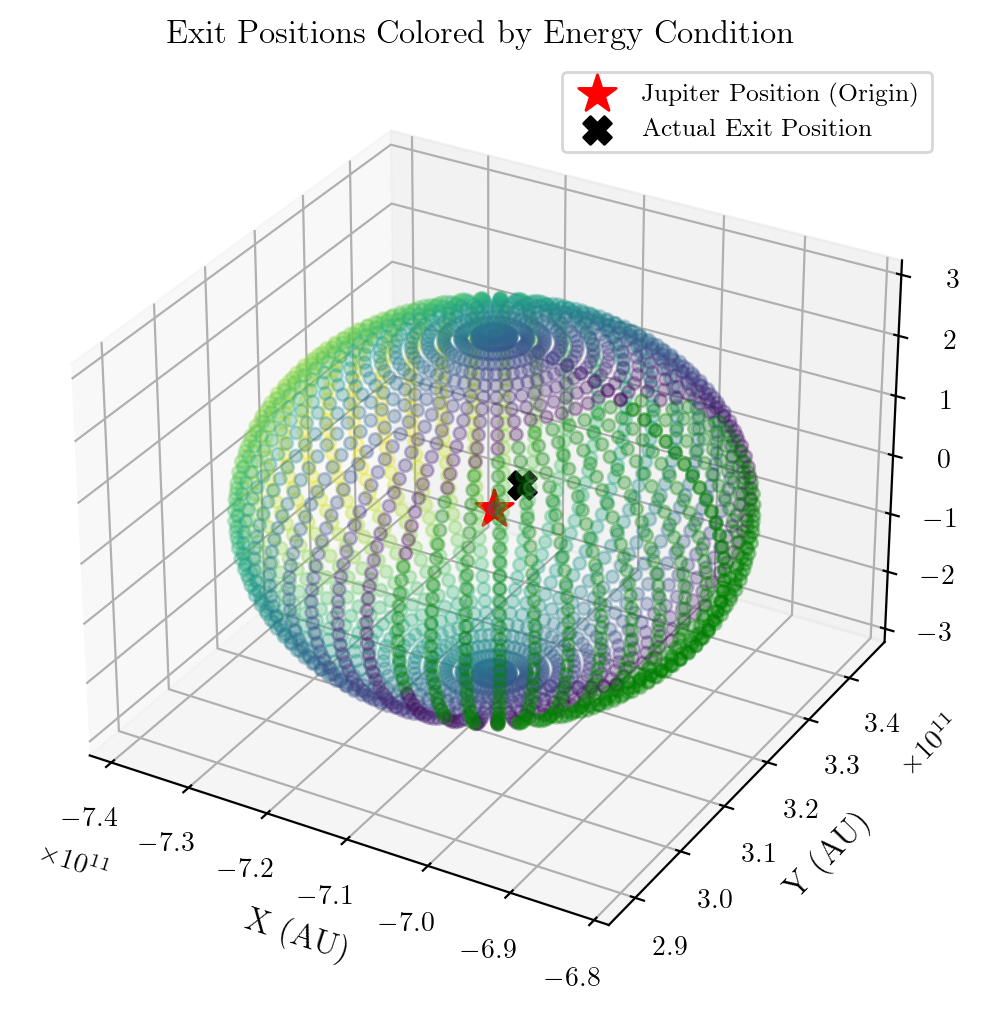

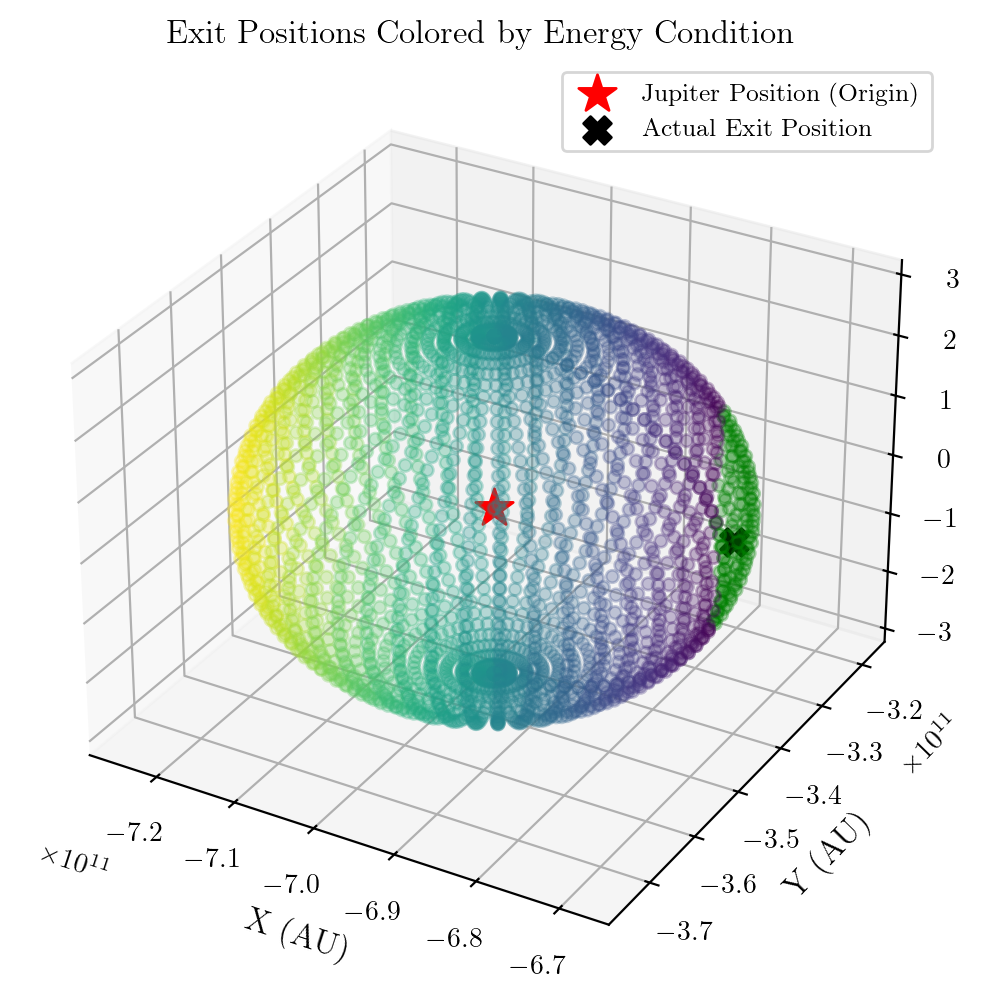

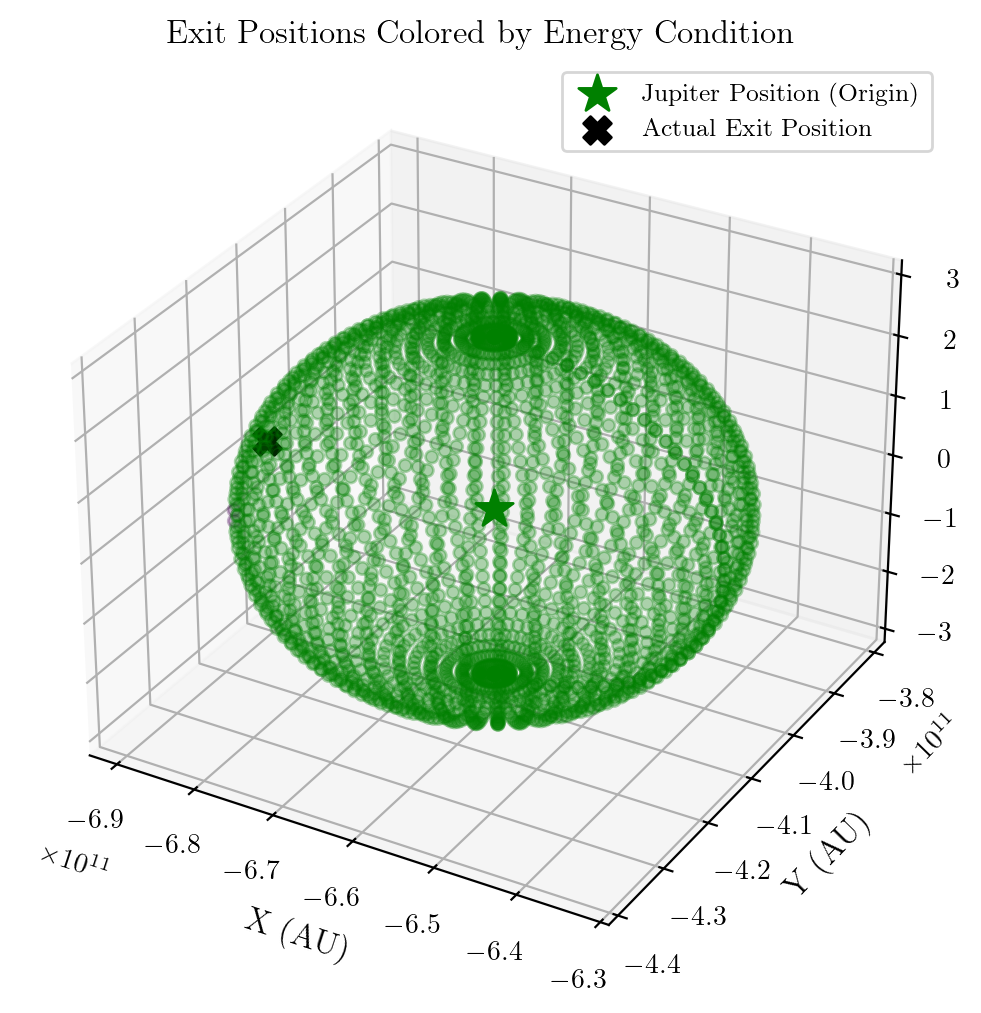

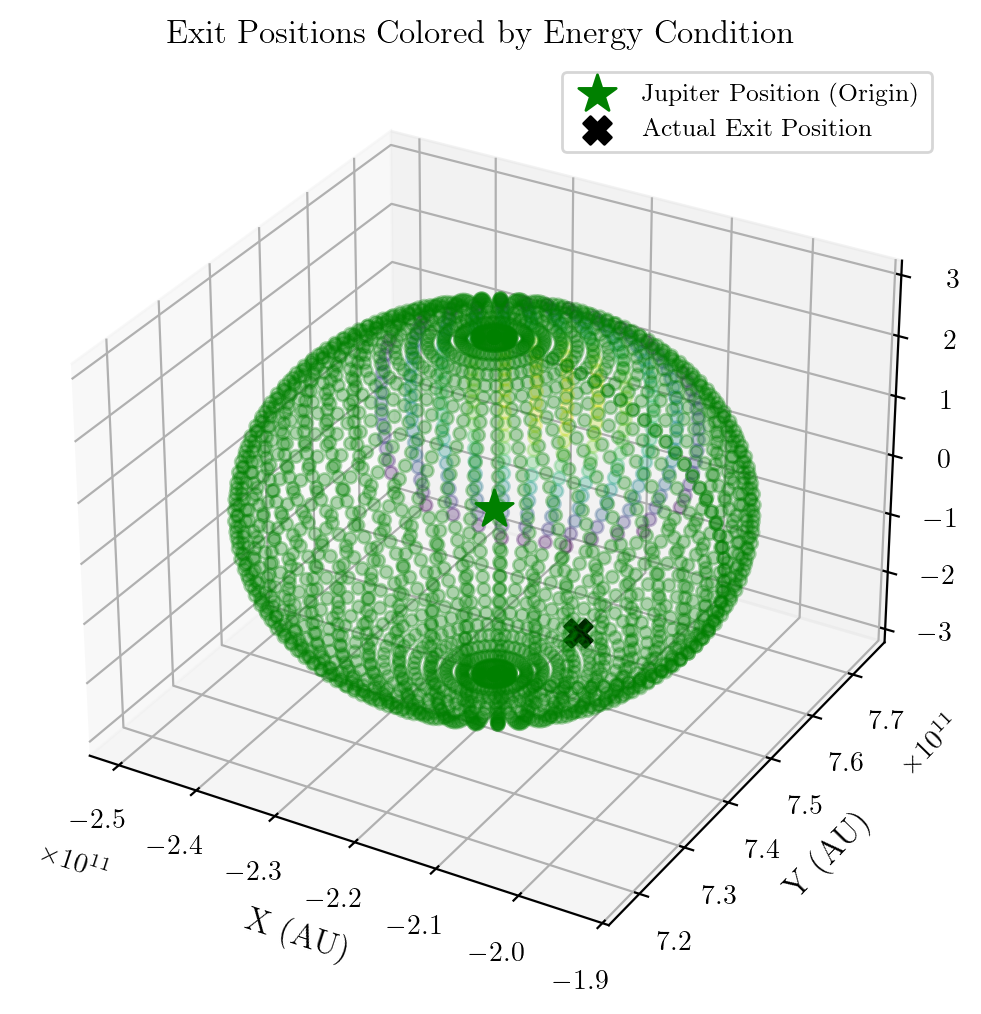

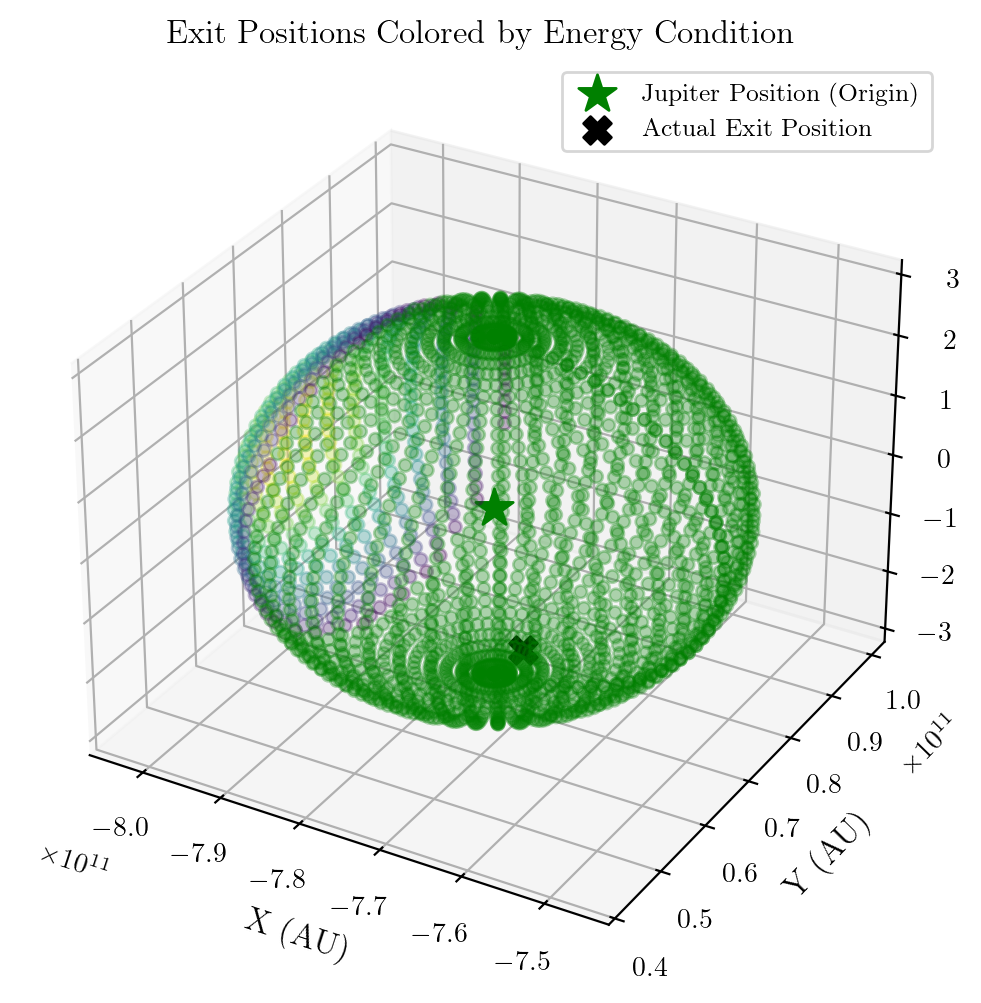

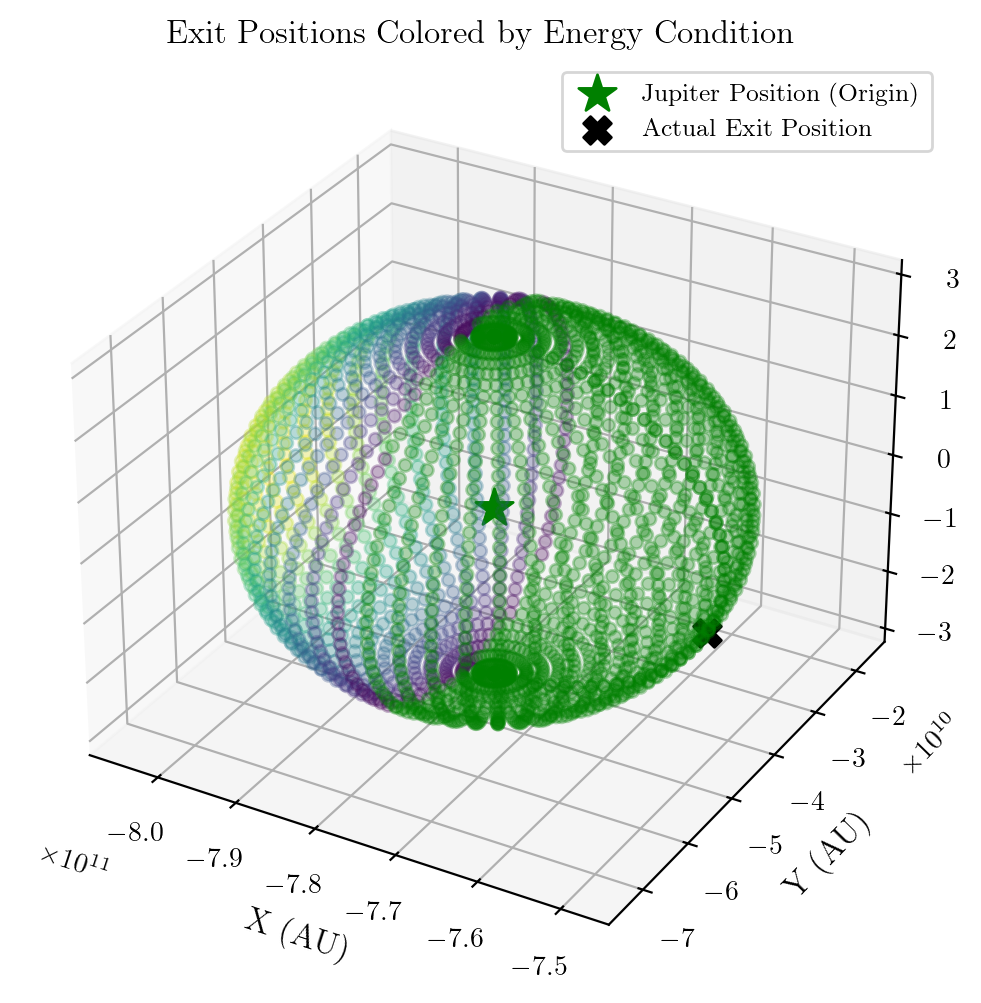

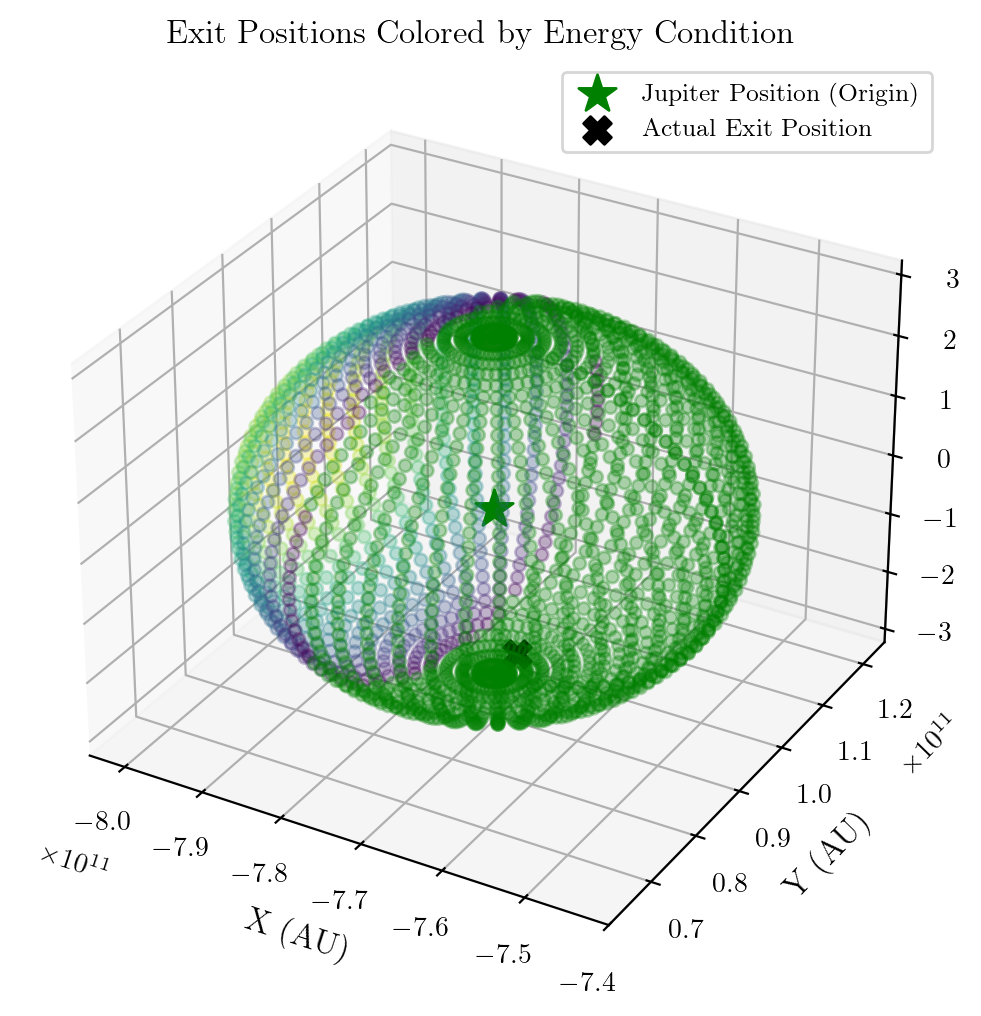

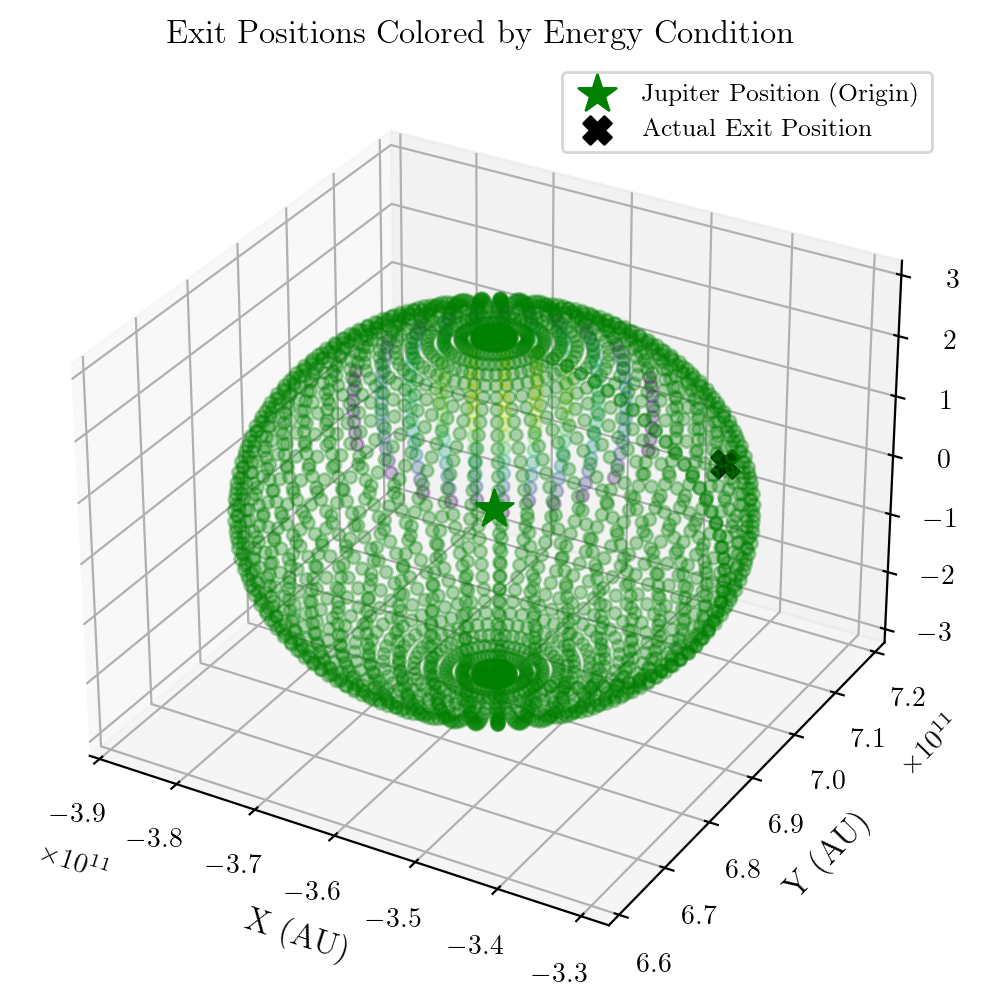

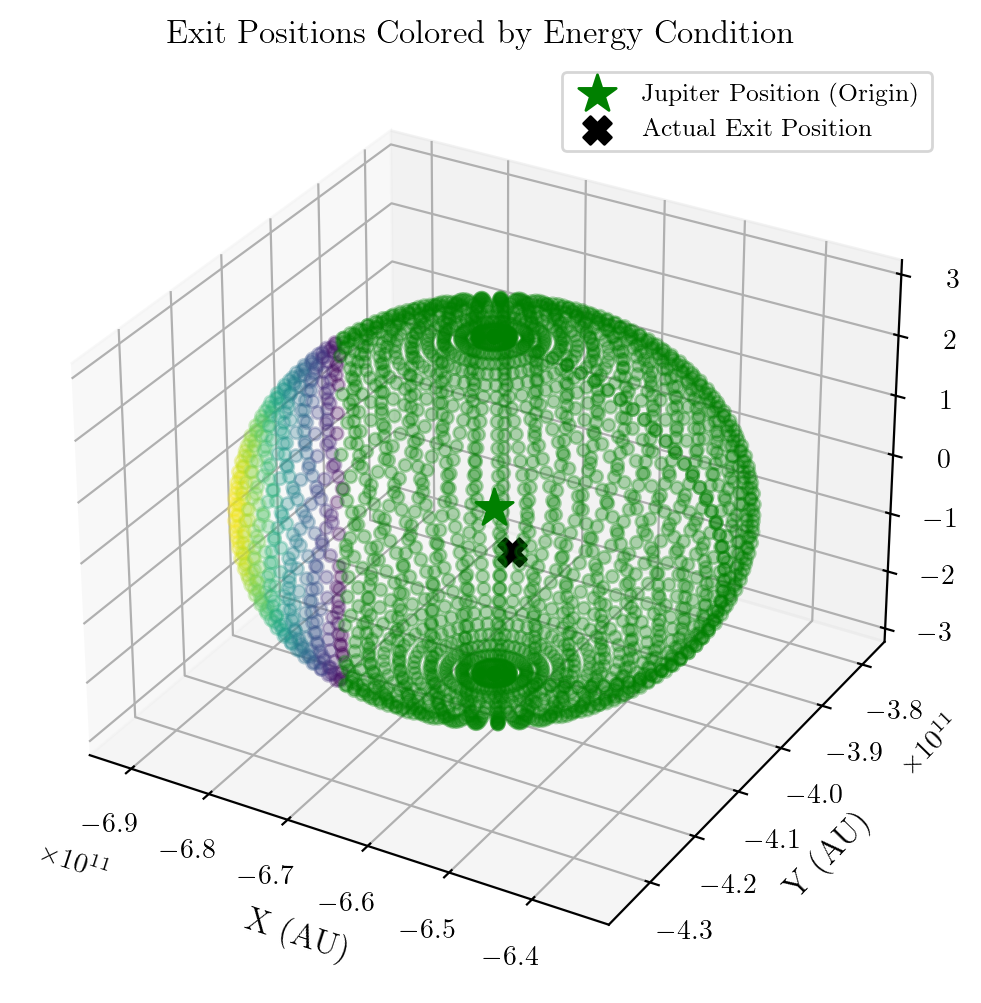

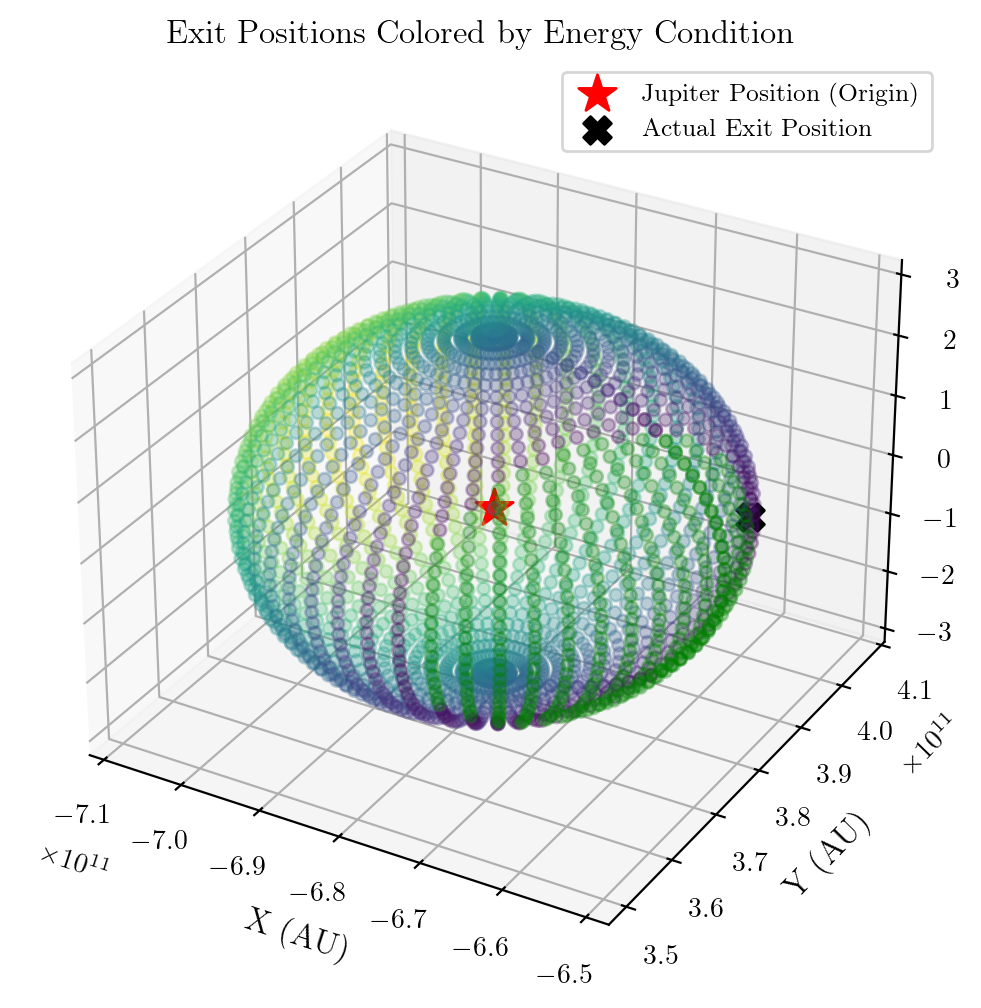

In [14]:
for v in sys_with_failed_capture.keys():
    v_inf = v
    for idx, data in list(sys_with_failed_capture[v].items())[0:1]:  # Just visualize the first one for now
        exit_positions = data['exit_positions']
        actual_exit = sampled_mc[v]['cap_C_pos'][idx]
        colors = data['colors']
        energies = data['energies']
        a_l = data['a_l']
        e_l = data['e_l']
        # energies_rebound = data['energies_rebound']
        pos_e = [e for e in energies if e > 0]
        # a_rebound = data['a_rebound']
        # e_rebound = data['e_rebound']
        # colors_rebound = data['colors_rebound']
        # Plotting
        fig = plt.figure(figsize=(6, 6))
        ax1 = fig.add_subplot(111, projection='3d')
        mask_pos = [e>0 for e in energies]
        mask_neg = [e<0 for e in energies]
        exit_masked = np.array(exit_positions)[mask_pos] 
        exit_masked_neg = np.array(exit_positions)[mask_neg]
        ax1.scatter([pos[0] for pos in exit_masked], [pos[1] for pos in exit_masked], [pos[2] for pos in exit_masked], c=pos_e, marker='o', alpha=0.3)

        ax1.scatter([pos[0] for pos in exit_masked_neg], [pos[1] for pos in exit_masked_neg], [pos[2] for pos in exit_masked_neg], c='green', marker='o', alpha=0.3)
        ax1.scatter(exit_positions[-1][0], exit_positions[-1][1], exit_positions[-1][2], c=colors[-1], marker='*', s=200, label='Jupiter Position (Origin)')
        ax1.scatter(actual_exit[0], actual_exit[1], actual_exit[2], c='black', marker='X', s=100, label='Actual Exit Position')
        ax1.legend()
        ax1.set_title('Exit Positions Colored by Energy Condition')
        ax1.set_xlabel('X (AU)')
        ax1.set_ylabel('Y (AU)')
        ax1.set_zlabel('Z (AU)')
        
        # ax2 = fig.add_subplot(122, projection='3d')
        # cc = [e for e in energies_rebound if not np.isclose(e, 0) else 'red']

        # ax2.scatter([pos[0] for pos in exit_positions], [pos[1] for pos in exit_positions], [pos[2] for pos in exit_positions], c=energies_rebound, marker='o', alpha=0.3)
        # ax2.scatter(actual_exit[0], actual_exit[1], actual_exit[2], c='black', marker='X', s=100, label='Actual Exit Position')
        # ax2.set_title('Exit Positions Colored by Rebound Capture Condition')
        # ax2.set_xlabel('X (AU)')
        # ax2.set_ylabel('Y (AU)')
        # ax2.set_zlabel('Z (AU)')
        
        # plt.suptitle(f"Failed Capture Trajectories for v_inf = {v_inf} m/s, idx = {idx}")
        plt.show()

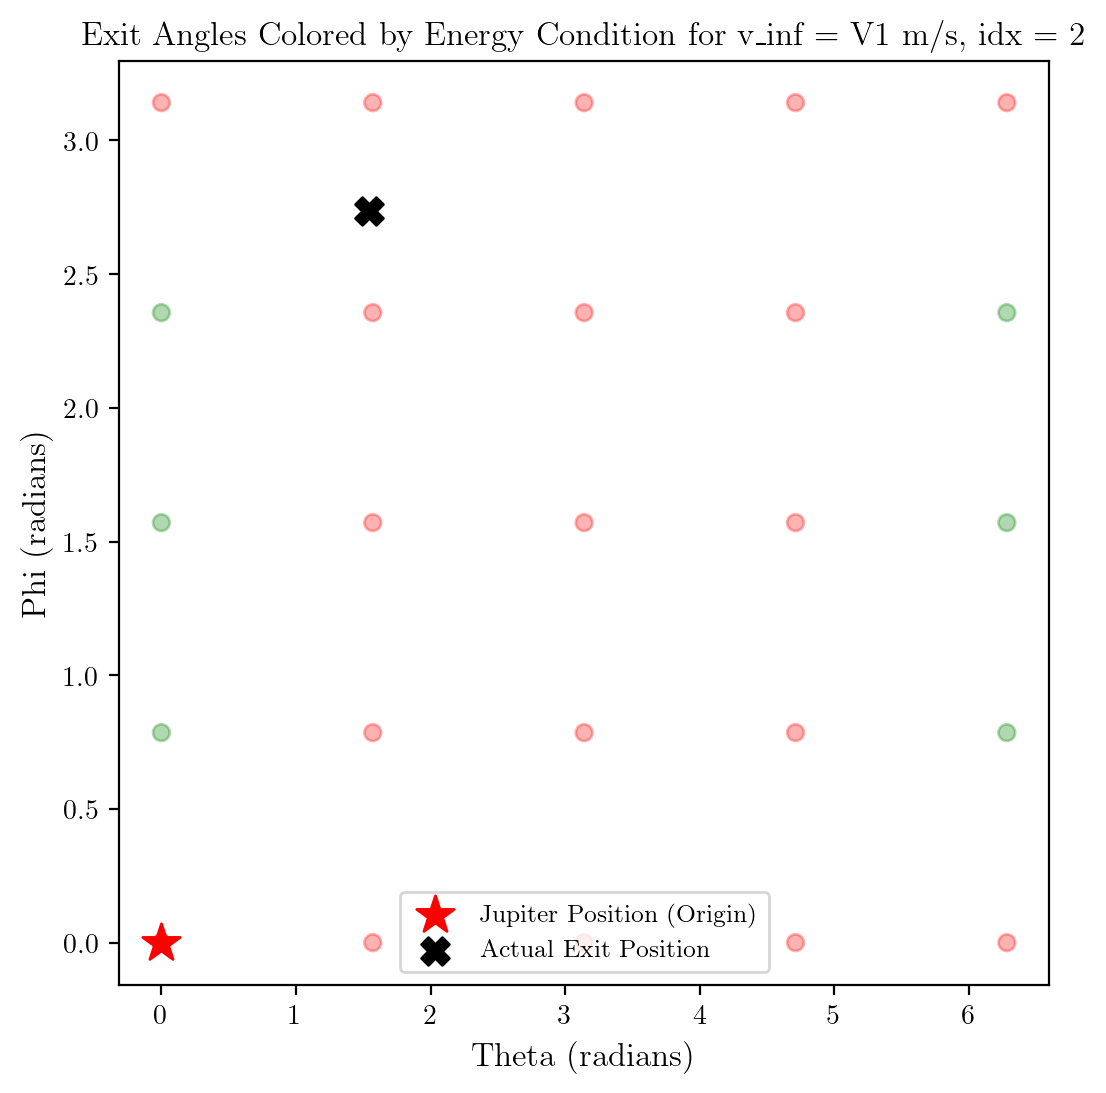

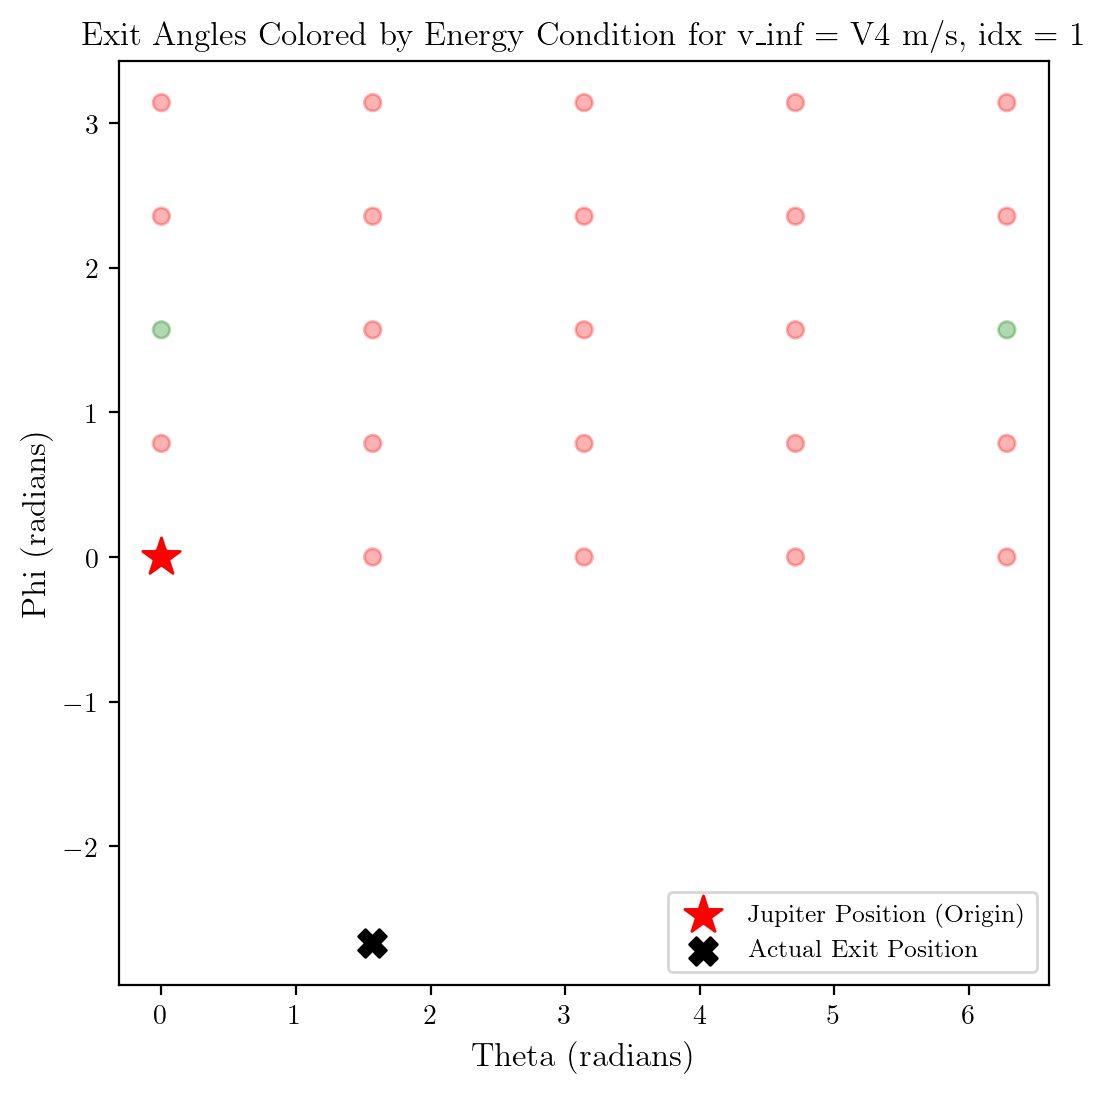

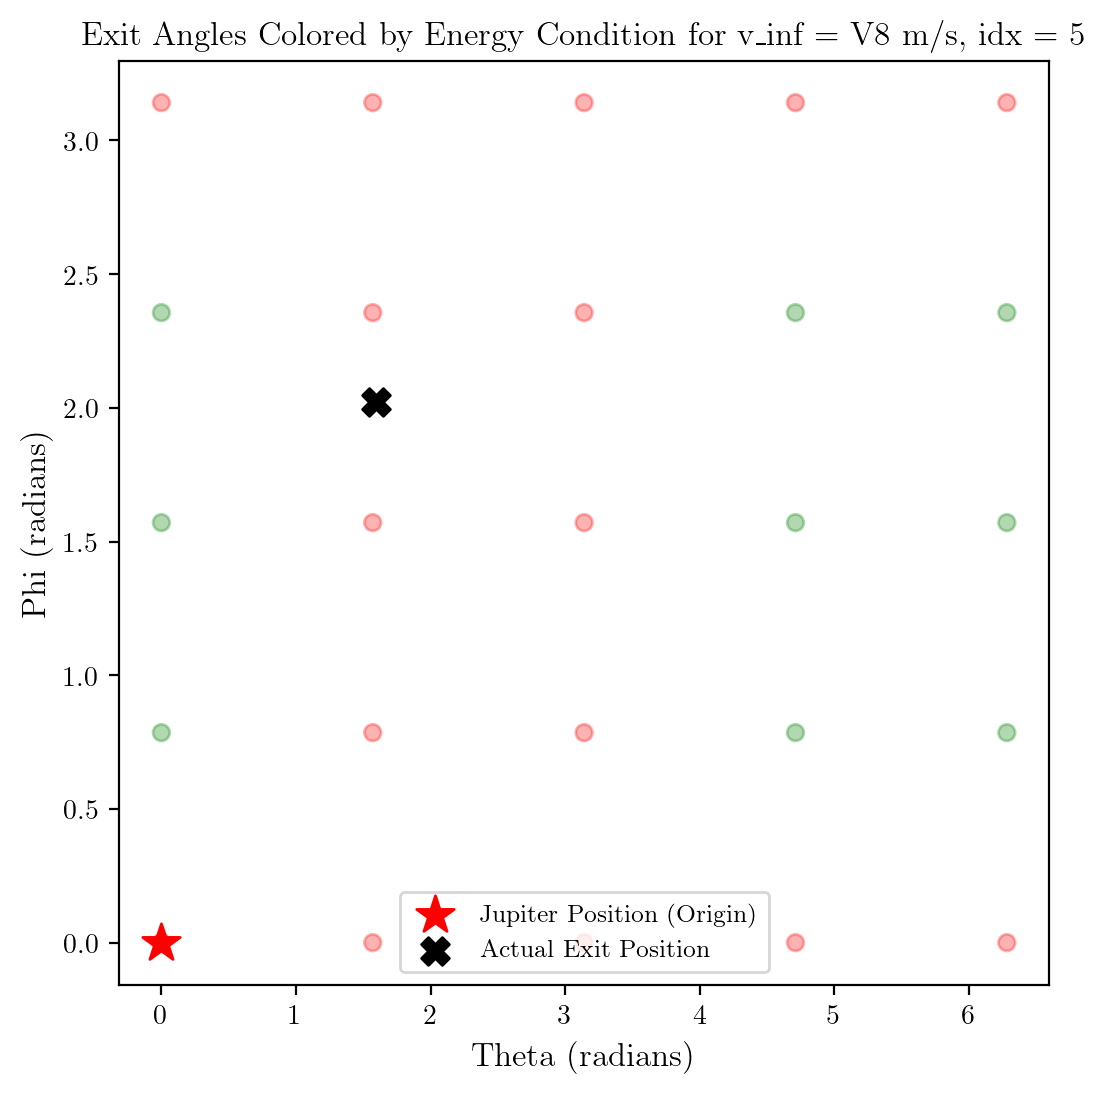

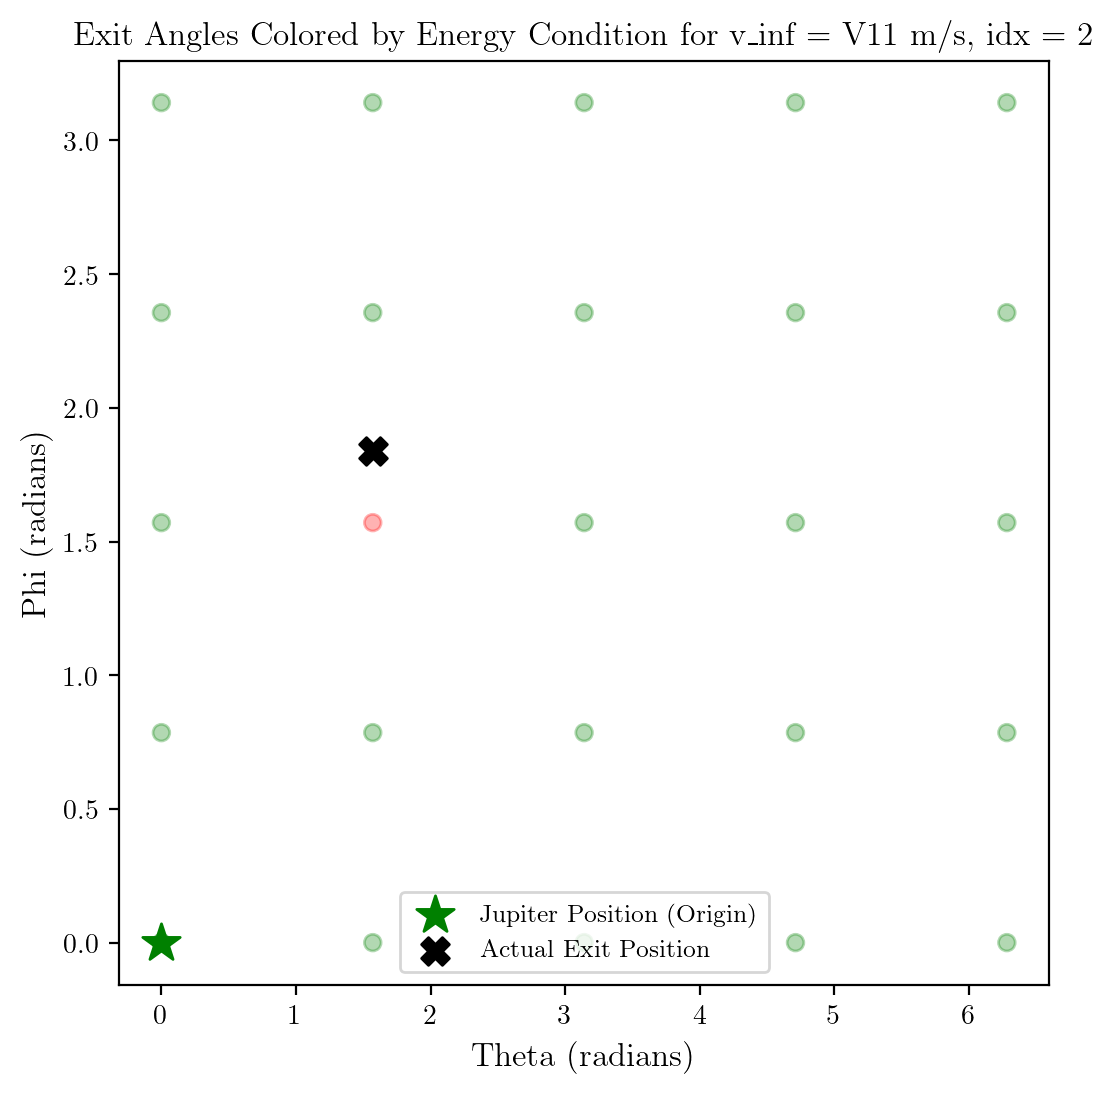

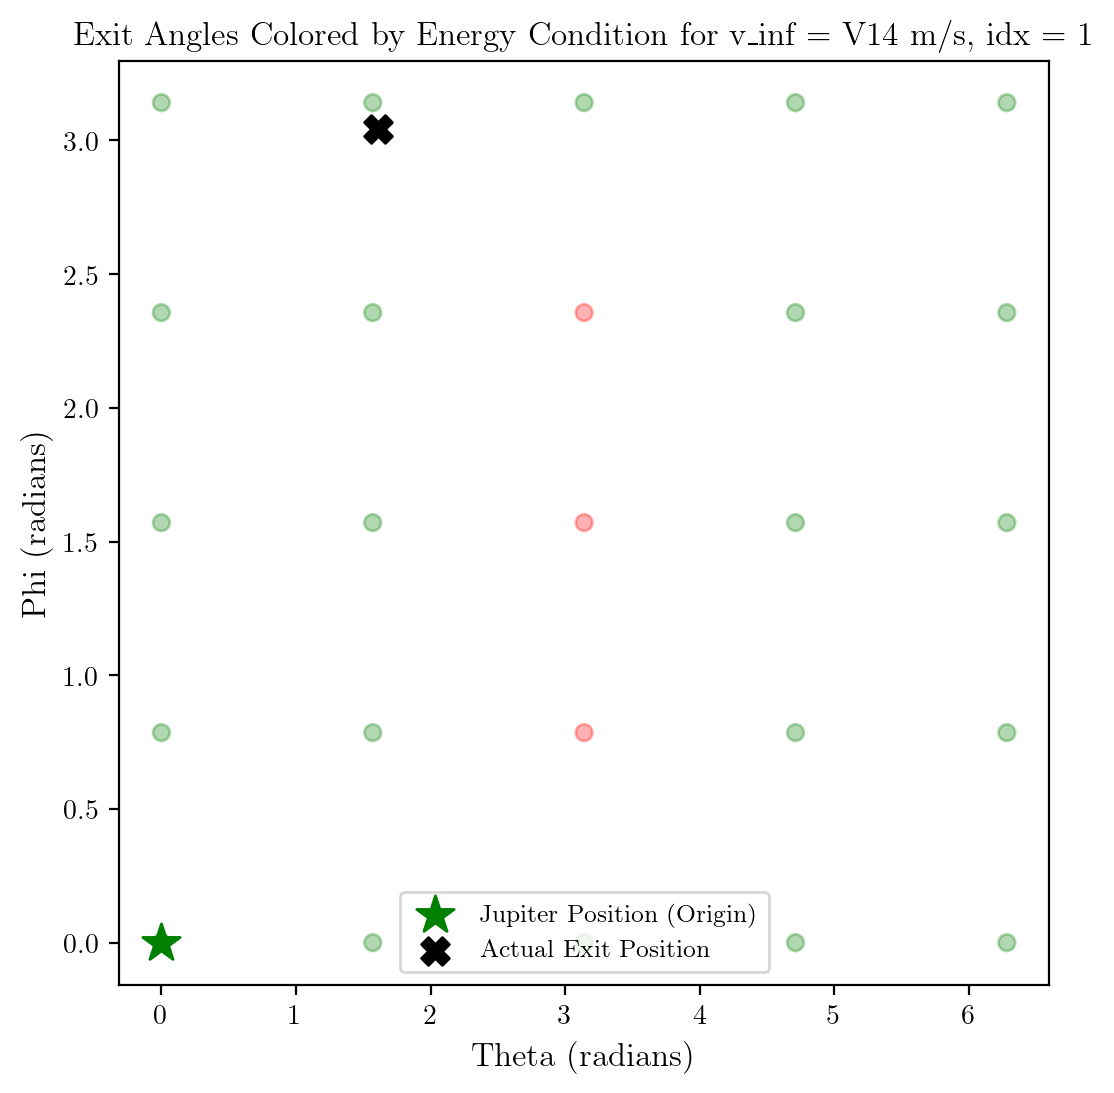

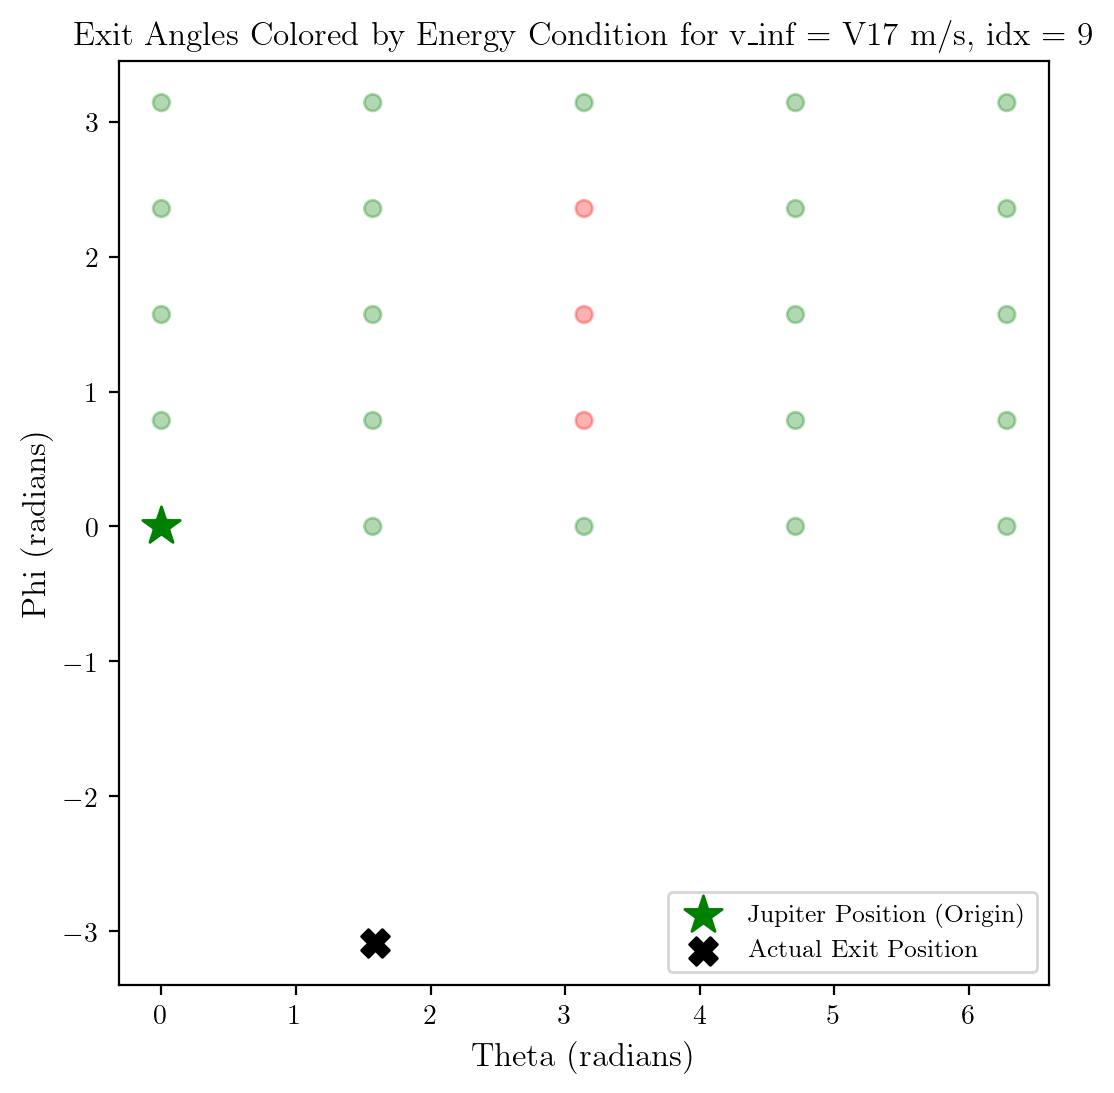

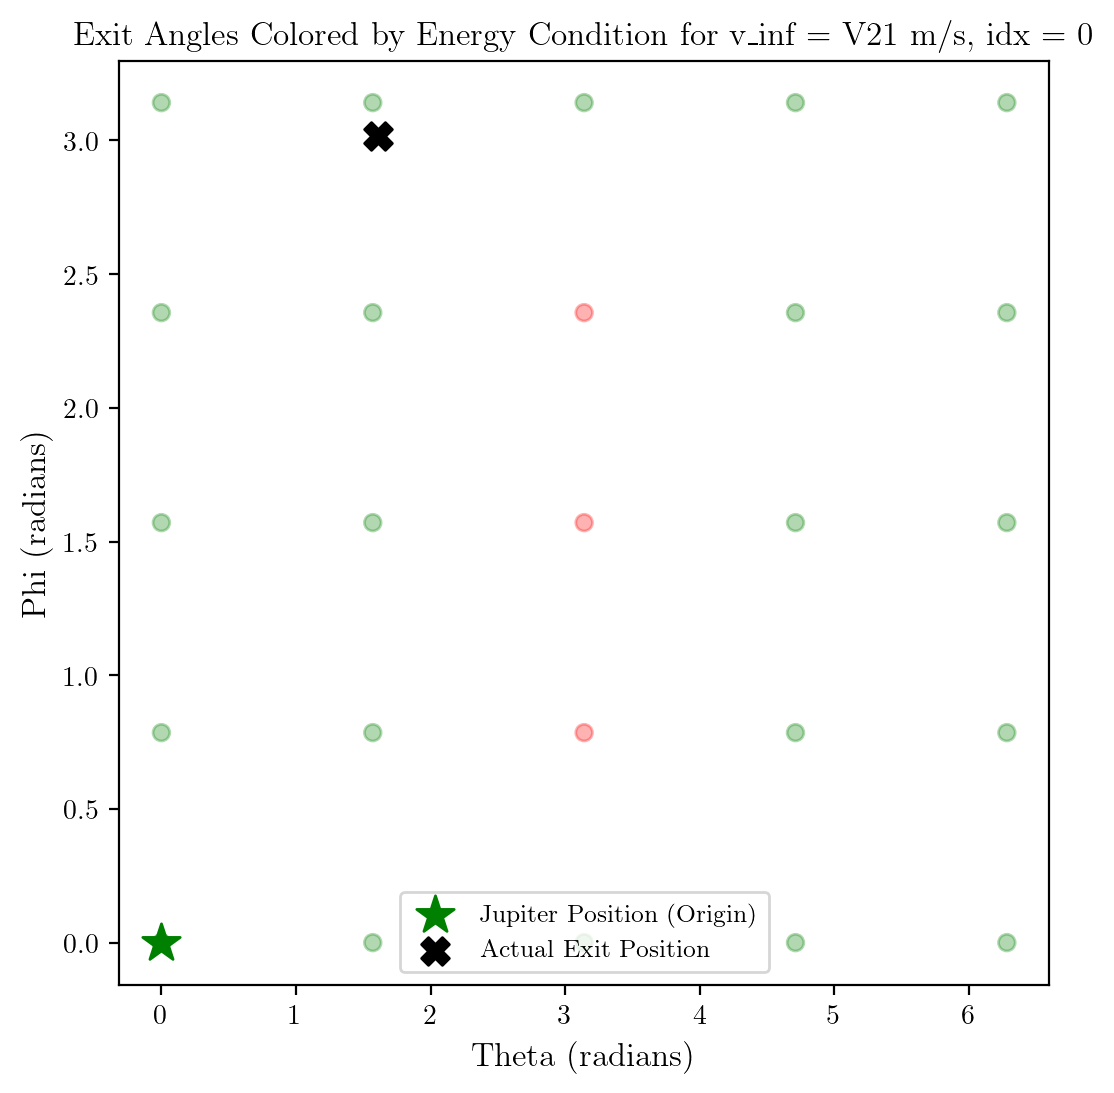

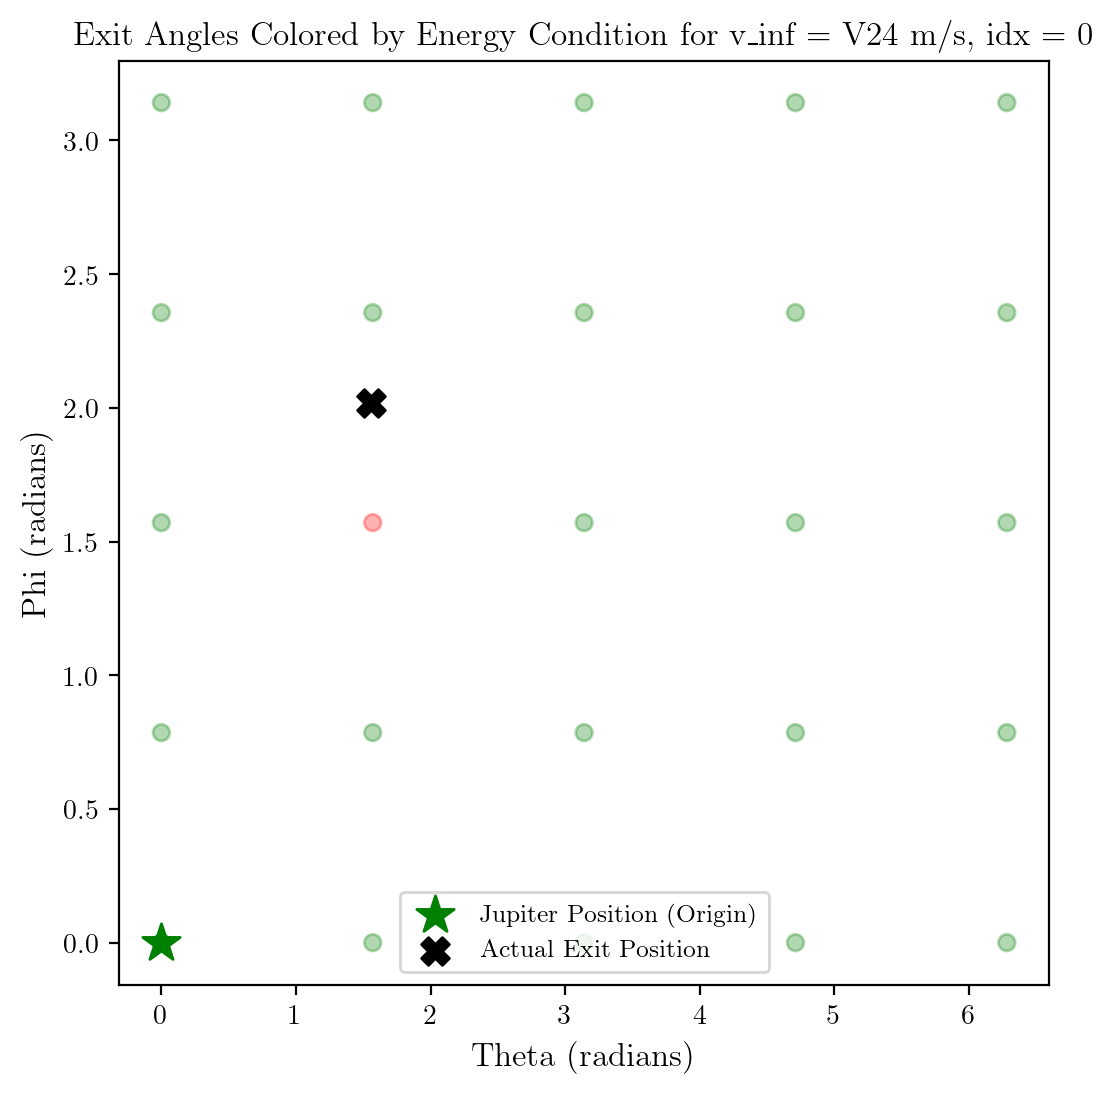

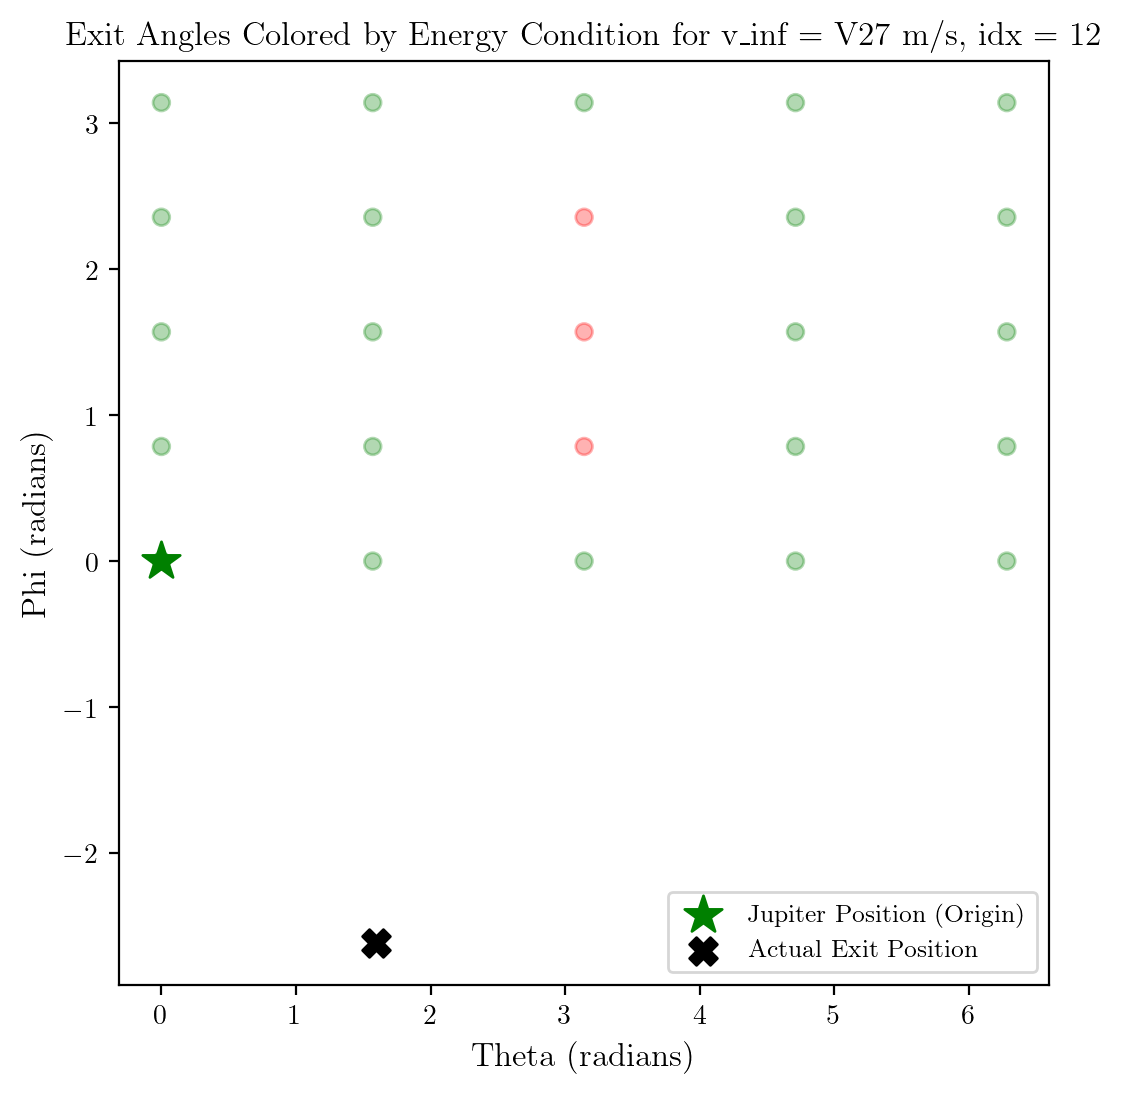

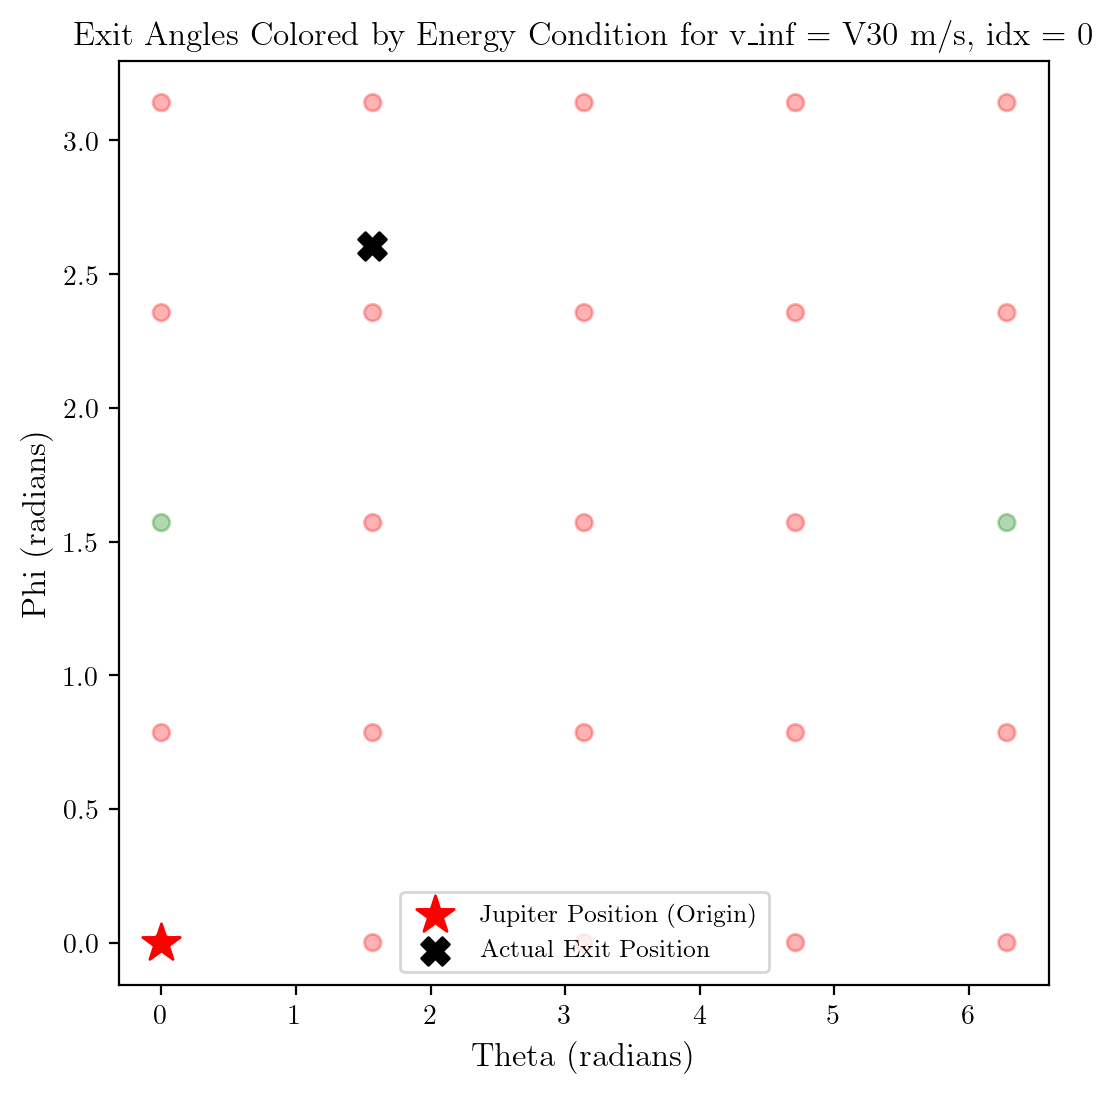

In [32]:
for v in sys_with_failed_capture.keys():
    v_inf = v
    for idx, data in list(sys_with_failed_capture[v].items())[0:1]:  # Just visualize the first one for now
        exit_positions = data['exit_positions']
        actual_exit = sampled_mc[v]['cap_C_pos'][idx]
        actual_exit_in_angles = calc.cartesian_to_spherical(actual_exit)
        colors = data['colors']
        energies = data['energies']
        exit_angles = data['exit_angles']
        exit_angles.append((0, 0))  # Add the actual exit position as (theta, phi) = (0, 0) for visualization
        ax1 = plt.figure(figsize=(6, 6)).add_subplot(111)
        ax1.scatter([angle[0] for angle in exit_angles], [angle[1] for angle in exit_angles], c=colors, marker='o', alpha=0.3)
        ax1.scatter(exit_angles[-1][0], exit_angles[-1][1], c=colors[-1], marker='*', s=200, label='Jupiter Position (Origin)')
        ax1.scatter(actual_exit_in_angles[1], actual_exit_in_angles[2], c='black', marker='X', s=100, label='Actual Exit Position')
        ax1.set_title(f'Exit Angles Colored by Energy Condition for v_inf = {v_inf} m/s, idx = {idx}')
        ax1.set_xlabel('Theta (radians)')
        ax1.set_ylabel('Phi (radians)')
        ax1.legend()
        plt.show()

In [ ]:
# Make corner plots with tdpy to visualize the distribution of exit positions and energies for the failed captures, and compare with the successful captures.
# labels of the populations
listlablpopl = ['Bound', 'Unbound']

# number of populations
numbpopl = len(listlablpopl)

# number of samples for each population
numbsamp = [100, 10000]

# number of features
numbfeat = 5

# generate samples
listpara = [[] for k in range(numbpopl)]
for k in range(numbpopl):

    # number of points
    numbdata = numbfeat * numbsamp[k]
    
    # samples
    listpara[k] = np.random.randn(numbdata).reshape((numbsamp[k], numbfeat)) + 5. * np.random.randn(numbfeat)[None, :]
for v in sys_with_failed_capture.keys():
    v_inf = v
    for idx, data in list(sys_with_failed_capture[v].items())[0:1]:  # Just visualize the first one for now
        
# labels of the parameters
listlablpara = []
for k in range(numbfeat):
    listlablpara.append(['$p_{%d}$' % k, ''])

typepgrp = 'both'
    
tdpy.plot_grid(listlablpara, listpara, listlablpopl=listlablpopl, typepgrp=typepgrp)